In [7]:
pip install timm torch torchvision torch-geometric
pip install transformers torch pillow requests


SyntaxError: invalid syntax (4089036214.py, line 1)

In [8]:
pip install torch transformers spacy networkx torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.8 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.1 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.0 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 69.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 57.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.9.41
    Uninstalling nvidia-nvjitlink-cu12-12.9.41:
      Successfully uninstalled nvidia-nvjitlin

In [9]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 87.6 MB/s eta 0:00:00:00:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import json
import pickle
from collections import Counter
import nltk

# Tải bộ tokenizer của nltk. Cần chạy một lần đầu tiên.
try:
    nltk.data.find('tokenizers/punkt')
except nltk.downloader.DownloadError:
    print("Đang tải tokenizer 'punkt' của NLTK...")
    nltk.download('punkt')
    print("Tải thành công!")

class Vocabulary:
    """
    Lớp xây dựng và quản lý từ điển từ các chú thích.
    """
    def __init__(self, threshold):
        """
        Args:
            threshold (int): Ngưỡng tần suất tối thiểu để một từ được đưa vào từ điển.
        """
        self.word2idx = {}
        self.idx2word = {}
        self.idx = 0
        self.threshold = threshold

    def add_word(self, word):
        """Thêm một từ vào từ điển."""
        if word not in self.word2idx:
            self.word2idx[word] = self.idx
            self.idx2word[self.idx] = word
            self.idx += 1

    def build_from_captions(self, captions_list):
        """
        Xây dựng từ điển từ một danh sách các câu chú thích.

        Args:
            captions_list (list): Danh sách các chuỗi chú thích.
        """
        print(f"Bắt đầu xây dựng từ điển từ {len(captions_list)} câu chú thích...")
        
        # 1. Đếm tần suất của tất cả các từ
        counter = Counter()
        for i, caption in enumerate(captions_list):
            # Tokenize câu (tách thành các từ) và chuyển thành chữ thường
            tokens = nltk.tokenize.word_tokenize(caption.lower())
            counter.update(tokens)
            
            if (i + 1) % 1000 == 0:
                print(f"  [Đã xử lý {i + 1}/{len(captions_list)} câu]")

        # 2. Lọc các từ có tần suất thấp
        # Giữ lại những từ có số lần xuất hiện >= threshold
        words = [word for word, count in counter.items() if count >= self.threshold]
        print(f"Tổng số từ duy nhất: {len(counter)}")
        print(f"Số từ sau khi lọc (tần suất >= {self.threshold}): {len(words)}")

        # 3. Thêm các token đặc biệt vào từ điển trước
        self.add_word('<pad>')  # ID: 0 - Dùng để đệm cho các câu có độ dài khác nhau
        self.add_word('<start>') # ID: 1 - Token bắt đầu câu
        self.add_word('<end>')   # ID: 2 - Token kết thúc câu
        self.add_word('<unk>')   # ID: 3 - Token cho các từ không có trong từ điển

        # 4. Thêm các từ đã lọc vào từ điển
        for word in words:
            self.add_word(word)

        print(f"Xây dựng từ điển hoàn tất. Tổng kích thước từ điển: {len(self.word2idx)}")

    def __call__(self, word):
        """Cho phép gọi vocab('word') để lấy ID."""
        if word not in self.word2idx:
            return self.word2idx['<unk>']
        return self.word2idx[word]

    def __len__(self):
        """Trả về kích thước của từ điển."""
        return len(self.word2idx)

def build_and_save_vocab(json_path, threshold, save_path):
    """
    Hàm chính để đọc file JSON, xây dựng và lưu từ điển.

    Args:
        json_path (str): Đường dẫn đến file captions.json.
        threshold (int): Ngưỡng tần suất từ.
        save_path (str): Đường dẫn để lưu file từ điển .pkl.
    """
    # Đọc file JSON
    print(f"Đang đọc file chú thích từ: {json_path}")
    with open(json_path, 'r') as f:
        data = json.load(f)

    # Lấy ra tất cả các câu chú thích từ cấu trúc file JSON
    all_captions = [ann['caption'] for ann in data['annotations']]

    # Khởi tạo và xây dựng từ điển
    vocab = Vocabulary(threshold=threshold)
    vocab.build_from_captions(all_captions)

    # Lưu từ điển vào file
    print(f"Đang lưu từ điển vào file: {save_path}")
    with open(save_path, 'wb') as f:
        pickle.dump(vocab, f)
    print("Lưu thành công!")
    return vocab

# ==========================================================
# --- PHẦN CHÍNH ĐỂ CHẠY ---
# ==========================================================
if __name__ == '__main__':
    # --- Cấu hình ---
    # Đường dẫn đến file annotation của bạn
    CAPTION_JSON_PATH = '/kaggle/input/2017-2017/annotations_trainval2017/annotations/captions_val2017.json'
    
    # Ngưỡng tần suất. Các từ xuất hiện ít hơn số này sẽ bị loại bỏ và coi là '<unk>'
    # Đây là một siêu tham số quan trọng, 5 là một giá trị khởi đầu tốt.
    WORD_THRESHOLD = 5
    
    # Đường dẫn để lưu file từ điển sau khi tạo xong
    VOCAB_SAVE_PATH = '/kaggle/working/vocab.pkl'

    # --- Chạy quá trình xây dựng ---
    vocab = build_and_save_vocab(
        json_path=CAPTION_JSON_PATH,
        threshold=WORD_THRESHOLD,
        save_path=VOCAB_SAVE_PATH
    )

    # --- Kiểm tra và ví dụ sử dụng từ điển đã tạo ---
    print("\n--- KIỂM TRA TỪ ĐIỂN ---")
    print(f"Kích thước từ điển: {len(vocab)}")
    print("Ví dụ chuyển đổi từ sang ID:")
    print(f"word 'a' -> id {vocab('a')}")
    print(f"word 'man' -> id {vocab('man')}")
    print(f"word '<start>' -> id {vocab('<start>')}")
    print(f"word 'xyz_unknown_word' -> id {vocab('xyz_unknown_word')} (ID của <unk>)")

    print("\nVí dụ chuyển đổi một câu sang chuỗi ID:")
    sentence = "A man is riding a horse on a beach."
    tokens = nltk.tokenize.word_tokenize(sentence.lower())
    ids = [vocab('<start>')] + [vocab(token) for token in tokens] + [vocab('<end>')]
    print(f"Câu: '{sentence}'")
    print(f"Tokens: {['<start>'] + tokens + ['<end>']}")
    print(f"IDs: {ids}")

GridGraphProcessor initialized on device: cuda
Maximum images to process: 1000
Model parameters: 16,992
Limited to first 1000 images out of 5000 total files
Using 1000 images from /kaggle/input/2017-2017/val2017/val2017
Processing batch 1/250 (4 images)
Processing batch 2/250 (4 images)
Processing batch 3/250 (4 images)
Processing batch 4/250 (4 images)
Processing batch 5/250 (4 images)
Processing batch 6/250 (4 images)
Processing batch 7/250 (4 images)
Processing batch 8/250 (4 images)
Processing batch 9/250 (4 images)
Processing batch 10/250 (4 images)
Processing batch 11/250 (4 images)
Processing batch 12/250 (4 images)
Processing batch 13/250 (4 images)
Processing batch 14/250 (4 images)
Processing batch 15/250 (4 images)
Processing batch 16/250 (4 images)
Processing batch 17/250 (4 images)
Processing batch 18/250 (4 images)
Processing batch 19/250 (4 images)
Processing batch 20/250 (4 images)
Processing batch 21/250 (4 images)
Processing batch 22/250 (4 images)
Processing batch 23

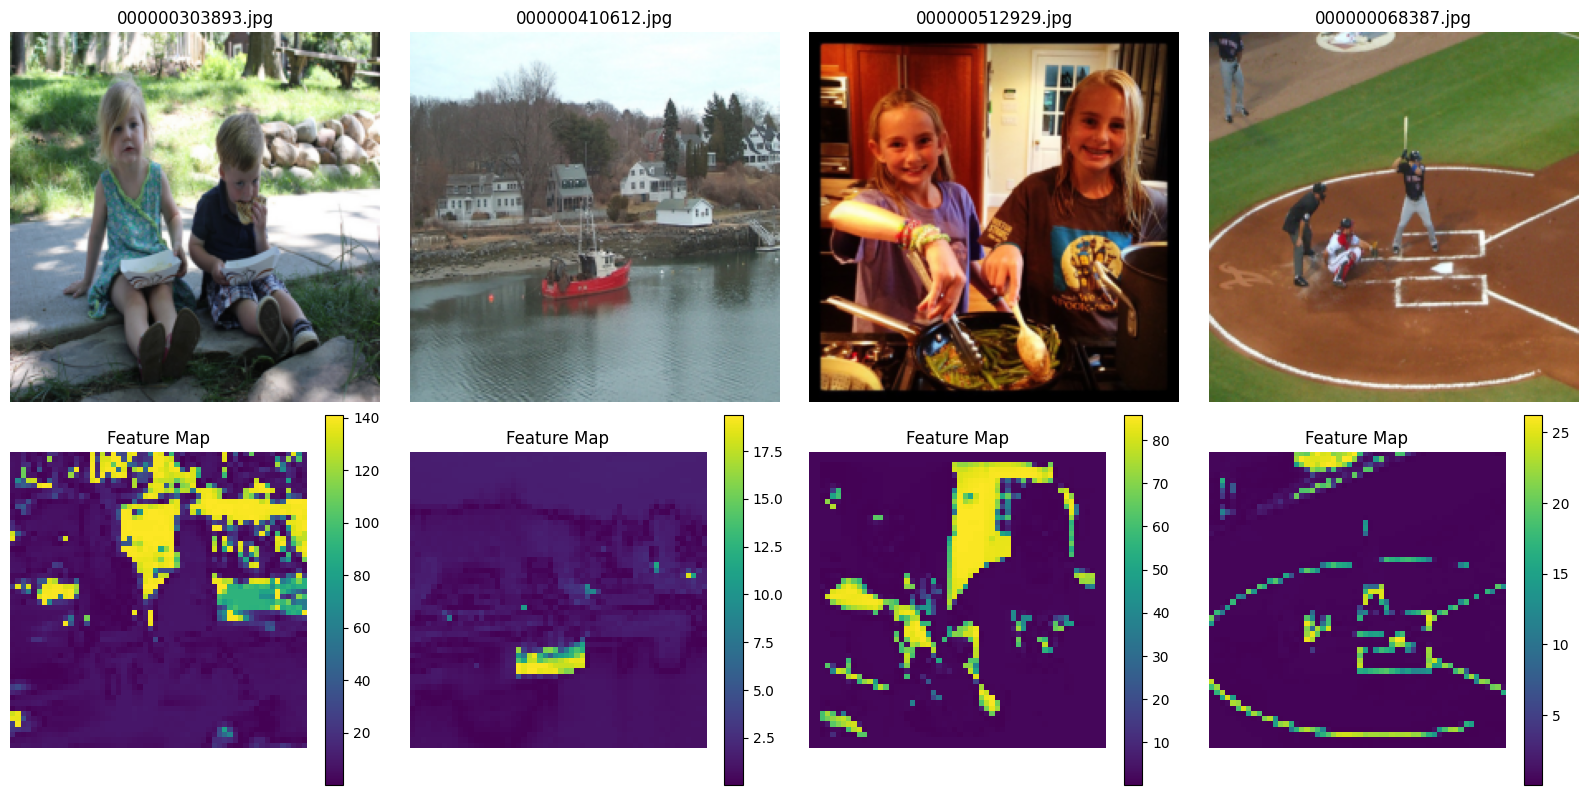

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from typing import Tuple, List, Dict
import math
import os
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

class ImageDataset(Dataset):
    """Dataset class for loading images from folder"""
    def __init__(self, folder_path: str, transform=None, max_images: int = 1000):
        self.folder_path = folder_path
        self.transform = transform
        self.max_images = max_images
        
        # Get all image files
        self.image_files = []
        valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif')
        
        for file in os.listdir(folder_path):
            if file.lower().endswith(valid_extensions):
                self.image_files.append(os.path.join(folder_path, file))
        
        # Limit to max_images
        if len(self.image_files) > self.max_images:
            self.image_files = self.image_files[:self.max_images]
            print(f"Limited to first {self.max_images} images out of {len(os.listdir(folder_path))} total files")
        
        if len(self.image_files) == 0:
            raise ValueError(f"No valid images found in {folder_path}")
        
        print(f"Using {len(self.image_files)} images from {folder_path}")
    
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        image_path = self.image_files[idx]
        image = Image.open(image_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        return image, os.path.basename(image_path)

class SwinTransformerPatchEmbedding(nn.Module):
    """Simplified Swin Transformer patch embedding for feature extraction"""
    def __init__(self, patch_size: int = 4, embed_dim: int = 96):
        super().__init__()
        self.patch_size = patch_size
        self.embed_dim = embed_dim
        self.proj = nn.Conv2d(3, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        # x: [B, C, H, W]
        x = self.proj(x)  # [B, embed_dim, H//patch_size, W//patch_size]
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)  # [B, H*W, C]
        return x, (H, W)

class GridGraphFeature(nn.Module):
    """
    Grid-graph feature extraction based on the paper description
    """
    def __init__(self,
                 image_size: int = 224,
                 patch_size: int = 4,
                 embed_dim: int = 96,
                 gcn_hidden_dim: int = 128):
        super().__init__()

        self.image_size = image_size
        self.patch_size = patch_size
        self.embed_dim = embed_dim
        self.gcn_hidden_dim = gcn_hidden_dim

        # Calculate number of patches
        self.num_patches_per_side = image_size // patch_size  # M = k = 56 for 224/4
        self.num_patches = self.num_patches_per_side ** 2     # M*k patches total

        # Swin Transformer for patch feature extraction
        self.swin_embedding = SwinTransformerPatchEmbedding(patch_size, embed_dim)

        # Graph Convolutional Layer
        self.gcn = GraphConvolutionalLayer(embed_dim, gcn_hidden_dim)

    def extract_patch_features(self, image: torch.Tensor) -> torch.Tensor:
        """
        Extract patch features using Swin Transformer
        Args:
            image: [B, 3, 224, 224] input image
        Returns:
            X^V: [B, M*k, embed_dim] patch feature matrix
        """
        # Split image into M x k patches and extract features
        patch_features, (H, W) = self.swin_embedding(image)  # [B, M*k, embed_dim]
        return patch_features

    def compute_similarity_matrix(self, patch_features: torch.Tensor) -> torch.Tensor:
        """
        Compute similarity matrix between patches
        Args:
            patch_features: [B, M*k, embed_dim] patch features
        Returns:
            A^V: [B, M*k, M*k] adjacency matrix
        """
        B, N, D = patch_features.shape
        k = self.num_patches_per_side

        # Normalize patch features for cosine similarity
        patch_features_norm = F.normalize(patch_features, p=2, dim=-1)

        # Compute cosine similarity matrix
        similarity_matrix = torch.bmm(patch_features_norm, patch_features_norm.transpose(-2, -1))

        # Initialize adjacency matrix
        adjacency_matrix = torch.zeros_like(similarity_matrix)

        # Create grid indices
        indices = torch.arange(N, device=patch_features.device).reshape(k, k)

        # Horizontal neighbors (right and left)
        right_neighbors = indices[:, :-1].flatten()  # i
        right_targets = indices[:, 1:].flatten()     # j
        left_neighbors = right_targets               # i
        left_targets = right_neighbors               # j

        # Vertical neighbors (down and up)
        down_neighbors = indices[:-1, :].flatten()   # i
        down_targets = indices[1:, :].flatten()      # j
        up_neighbors = down_targets                  # i
        up_targets = down_neighbors                  # j

        # Set adjacency for neighbors to 1
        adjacency_matrix[:, right_neighbors, right_targets] = 1.0
        adjacency_matrix[:, left_neighbors, left_targets] = 1.0
        adjacency_matrix[:, down_neighbors, down_targets] = 1.0
        adjacency_matrix[:, up_neighbors, up_targets] = 1.0

        # Set diagonal to 1
        adjacency_matrix[:, torch.arange(N), torch.arange(N)] = 1.0

        # Fill non-adjacent positions with similarity values
        mask = adjacency_matrix == 0
        adjacency_matrix[mask] = similarity_matrix[mask]

        return adjacency_matrix

    def forward(self, image: torch.Tensor) -> torch.Tensor:
        """
        Forward pass of grid-graph feature extraction
        Args:
            image: [B, 3, 224, 224] input image
        Returns:
            V^(0): [B, M*k, hidden_dim] initial context grid representation
        """
        # Step 1: Extract patch features using Swin Transformer
        patch_features = self.extract_patch_features(image)  # X^V

        # Step 2: Compute similarity-based adjacency matrix
        adjacency_matrix = self.compute_similarity_matrix(patch_features)  # A^V

        # Step 3: Apply Graph Convolutional Layer
        grid_representation = self.gcn(patch_features, adjacency_matrix)  # V^(0)

        return grid_representation

class GraphConvolutionalLayer(nn.Module):
    """
    Graph Convolutional Layer implementation
    V^(0) = σ(Ã^T VW^T)
    """
    def __init__(self, input_dim: int, output_dim: int):
        super().__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim

        # Weight matrix W
        self.weight = nn.Parameter(torch.FloatTensor(input_dim, output_dim))
        self.reset_parameters()

    def reset_parameters(self):
        stdv = 1. / math.sqrt(self.weight.size(1))
        self.weight.data.uniform_(-stdv, stdv)

    def forward(self, node_features: torch.Tensor, adjacency_matrix: torch.Tensor) -> torch.Tensor:
        """
        Args:
            node_features: [B, N, input_dim] node feature matrix V
            adjacency_matrix: [B, N, N] adjacency matrix A^V
        Returns:
            output: [B, N, output_dim] output features V^(0)
        """
        # Compute degree matrix D
        degree_matrix = torch.sum(adjacency_matrix, dim=-1, keepdim=True)  # [B, N, 1]
        degree_matrix = torch.clamp(degree_matrix, min=1.0)  # Avoid division by zero

        # Normalize adjacency matrix: Ã = D^(-1/2) A^V D^(-1/2)
        degree_inv_sqrt = torch.pow(degree_matrix, -0.5)
        normalized_adj = degree_inv_sqrt * adjacency_matrix * degree_inv_sqrt.transpose(-2, -1)

        # Apply weight transformation: VW^T
        transformed_features = torch.matmul(node_features, self.weight)  # [B, N, output_dim]

        # Graph convolution: Ã^T VW^T
        output = torch.bmm(normalized_adj.transpose(-2, -1), transformed_features)

        # Apply activation function (ReLU)
        output = F.relu(output)

        return output

class GridGraphProcessor:
    """
    Main processor class for handling folder input and batch processing
    """
    def __init__(self, 
                 image_size: int = 224,
                 patch_size: int = 4,
                 embed_dim: int = 96,
                 gcn_hidden_dim: int = 128,
                 batch_size: int = 8,
                 device: str = None,
                 max_images: int = 1000):
        
        self.batch_size = batch_size
        self.device = device if device else ('cuda' if torch.cuda.is_available() else 'cpu')
        self.max_images = max_images
        
        # Initialize model
        self.model = GridGraphFeature(
            image_size=image_size,
            patch_size=patch_size,
            embed_dim=embed_dim,
            gcn_hidden_dim=gcn_hidden_dim
        ).to(self.device)
        
        # Image preprocessing
        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                               std=[0.229, 0.224, 0.225])
        ])
        
        print(f"GridGraphProcessor initialized on device: {self.device}")
        print(f"Maximum images to process: {self.max_images}")
        print(f"Model parameters: {sum(p.numel() for p in self.model.parameters()):,}")
    
    def process_folder(self, folder_path: str, save_features: bool = True, 
                      output_dir: str = None) -> Dict:
        """
        Process images in a folder (limited to max_images)
        Args:
            folder_path: Path to folder containing images
            save_features: Whether to save extracted features
            output_dir: Directory to save features (default: folder_path + '_features')
        Returns:
            Dictionary containing features and metadata
        """
        if not os.path.exists(folder_path):
            raise ValueError(f"Folder path {folder_path} does not exist")
    
        # Create dataset and dataloader with max_images limit
        dataset = ImageDataset(folder_path, transform=self.transform, max_images=self.max_images)
        dataloader = DataLoader(dataset, batch_size=self.batch_size, 
                              shuffle=False, num_workers=4)
        
        # Prepare output directory
        if save_features:
            if output_dir is None:
                # Use a writable directory in Kaggle
                output_dir = '/kaggle/working/grid_graph_features'
            os.makedirs(output_dir, exist_ok=True)
        
        # Process images
        all_features = []
        all_filenames = []
        
        self.model.eval()
        with torch.no_grad():
            for batch_idx, (images, filenames) in enumerate(dataloader):
                print(f"Processing batch {batch_idx + 1}/{len(dataloader)} "
                      f"({len(images)} images)")
                
                # Move to device
                images = images.to(self.device)
                
                # Extract features
                features = self.model(images)  # [B, num_patches, hidden_dim]
                
                # Move back to CPU for storage
                features = features.cpu()
                
                all_features.append(features)
                all_filenames.extend(filenames)
        
        # Concatenate all features
        all_features = torch.cat(all_features, dim=0)  # [N_images, num_patches, hidden_dim]
        
        print(f"\nProcessing complete!")
        print(f"Total images processed: {len(all_filenames)} (limited to {self.max_images})")
        print(f"Feature tensor shape: {all_features.shape}")
        
        # Save features if requested
        if save_features:
            features_path = os.path.join(output_dir, 'grid_graph_features.pt')
            metadata_path = os.path.join(output_dir, 'metadata.pt')
            
            torch.save(all_features, features_path)
            torch.save({
                'filenames': all_filenames,
                'num_images_processed': len(all_filenames),
                'max_images_limit': self.max_images,
                'num_patches': self.model.num_patches,
                'feature_dim': self.model.gcn_hidden_dim,
                'model_config': {
                    'image_size': self.model.image_size,
                    'patch_size': self.model.patch_size,
                    'embed_dim': self.model.embed_dim,
                    'gcn_hidden_dim': self.model.gcn_hidden_dim
                }
            }, metadata_path)
            
            print(f"Features saved to: {features_path}")
            print(f"Metadata saved to: {metadata_path}")
        
        return {
            'features': all_features,
            'filenames': all_filenames,
            'metadata': {
                'num_patches': self.model.num_patches,
                'feature_dim': self.model.gcn_hidden_dim,
                'num_images_processed': len(all_filenames),
                'max_images_limit': self.max_images
            }
        }
    
    def visualize_features(self, folder_path: str, num_samples: int = 4):
        """
        Visualize some sample images and their feature representations
        """
        dataset = ImageDataset(folder_path, transform=self.transform, max_images=self.max_images)
        
        # Select random samples
        indices = np.random.choice(len(dataset), min(num_samples, len(dataset)), replace=False)
        
        fig, axes = plt.subplots(2, len(indices), figsize=(4*len(indices), 8))
        if len(indices) == 1:
            axes = axes.reshape(-1, 1)
        
        self.model.eval()
        with torch.no_grad():
            for i, idx in enumerate(indices):
                image, filename = dataset[idx]
                
                # Original image (denormalize for display)
                img_display = image.clone()
                img_display = img_display * torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
                img_display = img_display + torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
                img_display = torch.clamp(img_display, 0, 1)
                
                axes[0, i].imshow(img_display.permute(1, 2, 0))
                axes[0, i].set_title(f'{filename}')
                axes[0, i].axis('off')
                
                # Extract features
                image_batch = image.unsqueeze(0).to(self.device)
                features = self.model(image_batch)  # [1, num_patches, hidden_dim]
                
                # Visualize feature map (average across feature dimension)
                feature_map = features.mean(dim=-1).squeeze(0).cpu()  # [num_patches]
                feature_map = feature_map.reshape(self.model.num_patches_per_side, 
                                                self.model.num_patches_per_side)
                
                im = axes[1, i].imshow(feature_map, cmap='viridis')
                axes[1, i].set_title('Feature Map')
                axes[1, i].axis('off')
                plt.colorbar(im, ax=axes[1, i])
        
        plt.tight_layout()
        plt.show()

# Example usage and testing
def test_folder_processing():
    """Test the folder processing functionality with 1000 images limit"""
    
    # Create a dummy folder with sample images (for testing)
    test_folder = "/kaggle/input/2017-2017/val2017/val2017"
    if not os.path.exists(test_folder):
        os.makedirs(test_folder)
        print(f"Created test folder: {test_folder}")
        print("Please add some images to this folder and run again.")
        return
    
    # Initialize processor with 1000 images limit
    processor = GridGraphProcessor(
        image_size=224,
        patch_size=4,
        embed_dim=96,
        gcn_hidden_dim=128,
        batch_size=4,
        max_images=1000  # Limit to 1000 images
    )
    
    # Process folder
    try:
        results = processor.process_folder(
            folder_path=test_folder,
            save_features=True
        )
        
        print("\n--- Processing Results ---")
        print(f"Number of images processed: {len(results['filenames'])}")
        print(f"Maximum images limit: {results['metadata']['max_images_limit']}")
        print(f"Feature shape: {results['features'].shape}")
        print(f"Sample filenames: {results['filenames'][:5]}")
        
        # Visualize some examples
        if len(results['filenames']) > 0:
            processor.visualize_features(test_folder, num_samples=min(4, len(results['filenames'])))
            
    except ValueError as e:
        print(f"Error: {e}")
        print("Please make sure the test folder contains valid image files.")

if __name__ == "__main__":
    test_folder_processing()

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from torchvision.models import detection
import numpy as np
import json
import os
from PIL import Image
import pickle
from tqdm import tqdm
import math

class RegionGraphFeatureExtractor:
    def __init__(self, device='cuda', confidence_threshold=0.5, max_objects=36):
        """
        Initialize Region-Graph Feature Extractor
        Args:
            device: cuda or cpu
            confidence_threshold: minimum confidence for object detection
            max_objects: maximum number of objects to extract per image
        """
        self.device = device
        self.confidence_threshold = confidence_threshold
        self.max_objects = max_objects
        
        # Load pre-trained Faster R-CNN
        print("Loading Faster R-CNN model...")
        self.model = detection.fasterrcnn_resnet50_fpn(pretrained=True)
        self.model.to(device)
        self.model.eval()
        
        # Image preprocessing
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                               std=[0.229, 0.224, 0.225])
        ])
        
        print(f"Model loaded successfully on {device}")
    
    def extract_region_features(self, image_path):
        """
        Extract region features from a single image
        Args:
            image_path: path to the image
        Returns:
            dict: containing region features, bounding boxes, and spatial features
        """
        try:
            # Load and preprocess image
            image = Image.open(image_path).convert('RGB')
            original_size = image.size  # (width, height)
            
            # Transform image for model input
            image_tensor = self.transform(image).unsqueeze(0).to(self.device)
            
            # Extract features using Faster R-CNN
            with torch.no_grad():
                outputs = self.model(image_tensor)
            
            # Parse outputs
            if len(outputs) == 0:
                return self._create_empty_features()
            
            output = outputs[0]
            boxes = output['boxes']
            scores = output['scores']
            labels = output['labels']
            
            # Filter by confidence threshold
            valid_indices = scores > self.confidence_threshold
            boxes = boxes[valid_indices]
            scores = scores[valid_indices]
            labels = labels[valid_indices]
            
            # Limit to max_objects
            if len(boxes) > self.max_objects:
                top_indices = torch.argsort(scores, descending=True)[:self.max_objects]
                boxes = boxes[top_indices]
                scores = scores[top_indices]
                labels = labels[top_indices]
            
            if len(boxes) == 0:
                return self._create_empty_features()
            
            # Extract visual features using RoI pooling
            visual_features = self._extract_visual_features(image_tensor, boxes)
            
            # Compute spatial features
            spatial_features = self._compute_spatial_features(boxes, original_size)
            
            # Create region graph
            graph_features = self._create_region_graph(boxes, visual_features, spatial_features)
            
            return {
                'visual_features': visual_features.cpu().numpy(),
                'spatial_features': spatial_features.cpu().numpy(),
                'boxes': boxes.cpu().numpy(),
                'scores': scores.cpu().numpy(),
                'labels': labels.cpu().numpy(),
                'graph_features': graph_features,
                'num_objects': len(boxes),
                'image_size': original_size
            }
            
        except Exception as e:
            print(f"Error processing {image_path}: {str(e)}")
            return self._create_empty_features()
    
    def _extract_visual_features(self, image_tensor, boxes):
        """
        Extract visual features using RoI pooling
        """
        # Get feature maps from backbone
        with torch.no_grad():
            # Access the backbone feature extractor
            backbone = self.model.backbone
            features = backbone(image_tensor)
            
            # Use the feature map from the last layer
            feature_map = features['pool']  # Shape: [1, 2048, H', W']
            
            # Perform RoI pooling manually
            roi_features = []
            for box in boxes:
                # Normalize box coordinates to feature map size
                h, w = feature_map.shape[2], feature_map.shape[3]
                img_h, img_w = image_tensor.shape[2], image_tensor.shape[3]
                
                # Scale box coordinates
                x1 = int(box[0] * w / img_w)
                y1 = int(box[1] * h / img_h)
                x2 = int(box[2] * w / img_w)
                y2 = int(box[3] * h / img_h)
                
                # Ensure valid coordinates
                x1, y1 = max(0, x1), max(0, y1)
                x2, y2 = min(w-1, x2), min(h-1, y2)
                
                if x2 > x1 and y2 > y1:
                    roi_feat = feature_map[0, :, y1:y2+1, x1:x2+1]
                    roi_feat = F.adaptive_avg_pool2d(roi_feat.unsqueeze(0), (1, 1))
                    roi_features.append(roi_feat.squeeze())
                else:
                    # Create zero feature for invalid box
                    roi_features.append(torch.zeros(2048, device=self.device))
            
            if roi_features:
                return torch.stack(roi_features)
            else:
                return torch.zeros((1, 2048), device=self.device)
    
    def _compute_spatial_features(self, boxes, image_size):
        """
        Compute spatial features for each bounding box
        """
        img_w, img_h = image_size
        spatial_features = []
        
        for box in boxes:
            x1, y1, x2, y2 = box
            
            # Normalize coordinates
            x1_norm = x1 / img_w
            y1_norm = y1 / img_h
            x2_norm = x2 / img_w
            y2_norm = y2 / img_h
            
            # Calculate additional spatial features
            w_norm = x2_norm - x1_norm
            h_norm = y2_norm - y1_norm
            area_norm = w_norm * h_norm
            
            # Center coordinates
            cx_norm = (x1_norm + x2_norm) / 2
            cy_norm = (y1_norm + y2_norm) / 2
            
            spatial_feat = torch.tensor([
                x1_norm, y1_norm, x2_norm, y2_norm,  # bbox coordinates
                w_norm, h_norm, area_norm,            # width, height, area
                cx_norm, cy_norm                      # center coordinates
            ], device=self.device)
            
            spatial_features.append(spatial_feat)
        
        return torch.stack(spatial_features) if spatial_features else torch.zeros((1, 9), device=self.device)
    
    def _create_region_graph(self, boxes, visual_features, spatial_features):
        """
        Create region graph with adjacency matrix and edge features
        """
        num_objects = len(boxes)
        
        # Create adjacency matrix based on spatial overlap and distance
        adjacency_matrix = torch.zeros((num_objects, num_objects), device=self.device)
        edge_features = []
        
        for i in range(num_objects):
            for j in range(num_objects):
                if i != j:
                    # Calculate IoU (Intersection over Union)
                    iou = self._calculate_iou(boxes[i], boxes[j])
                    
                    # Calculate spatial distance
                    dist = self._calculate_distance(boxes[i], boxes[j])
                    
                    # Create edge if IoU > threshold or distance < threshold
                    if iou > 0.1 or dist < 0.3:
                        adjacency_matrix[i, j] = 1.0
                        
                        # Edge features: [iou, distance, relative_position_x, relative_position_y]
                        rel_pos = self._calculate_relative_position(boxes[i], boxes[j])
                        edge_feat = torch.tensor([iou, dist, rel_pos[0], rel_pos[1]], 
                                                device=self.device)
                        edge_features.append(edge_feat)
                    else:
                        edge_features.append(torch.zeros(4, device=self.device))
        
        edge_features = torch.stack(edge_features).reshape(num_objects, num_objects, -1)
        
        return {
            'adjacency_matrix': adjacency_matrix.cpu().numpy(),
            'edge_features': edge_features.cpu().numpy(),
            'node_features': torch.cat([visual_features, spatial_features], dim=1).cpu().numpy()
        }
    
    def _calculate_iou(self, box1, box2):
        """Calculate Intersection over Union"""
        x1_inter = max(box1[0], box2[0])
        y1_inter = max(box1[1], box2[1])
        x2_inter = min(box1[2], box2[2])
        y2_inter = min(box1[3], box2[3])
        
        if x2_inter <= x1_inter or y2_inter <= y1_inter:
            return 0.0
        
        inter_area = (x2_inter - x1_inter) * (y2_inter - y1_inter)
        box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
        box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
        
        union_area = box1_area + box2_area - inter_area
        return inter_area / union_area if union_area > 0 else 0.0
    
    def _calculate_distance(self, box1, box2):
        """Calculate normalized distance between box centers"""
        cx1 = (box1[0] + box1[2]) / 2
        cy1 = (box1[1] + box1[3]) / 2
        cx2 = (box2[0] + box2[2]) / 2
        cy2 = (box2[1] + box2[3]) / 2
        
        dist = math.sqrt((cx1 - cx2)**2 + (cy1 - cy2)**2)
        # Normalize by image diagonal (assuming max image size ~800)
        return dist / 800.0
    
    def _calculate_relative_position(self, box1, box2):
        """Calculate relative position between two boxes"""
        cx1 = (box1[0] + box1[2]) / 2
        cy1 = (box1[1] + box1[3]) / 2
        cx2 = (box2[0] + box2[2]) / 2
        cy2 = (box2[1] + box2[3]) / 2
        
        return [(cx2 - cx1) / 800.0, (cy2 - cy1) / 800.0]
    
    def _create_empty_features(self):
        """Create empty features when no objects detected"""
        return {
            'visual_features': np.zeros((1, 2048)),
            'spatial_features': np.zeros((1, 9)),
            'boxes': np.zeros((1, 4)),
            'scores': np.zeros(1),
            'labels': np.zeros(1),
            'graph_features': {
                'adjacency_matrix': np.zeros((1, 1)),
                'edge_features': np.zeros((1, 1, 4)),
                'node_features': np.zeros((1, 2057))
            },
            'num_objects': 0,
            'image_size': (224, 224)
        }


def extract_coco_features(coco_images_dir, coco_annotations_file, output_dir, num_images=1000):
    """
    Extract region-graph features from COCO dataset
    Args:
        coco_images_dir: directory containing COCO images
        coco_annotations_file: COCO annotations JSON file
        output_dir: directory to save extracted features
        num_images: number of images to process (default: 1000)
    """
    # Create output directory
    os.makedirs(output_dir, exist_ok=True)
    
    # Load COCO annotations
    print("Loading COCO annotations...")
    with open(coco_annotations_file, 'r') as f:
        coco_data = json.load(f)
    
    # Get first 1000 images
    images = coco_data['images'][:num_images]
    print(f"Processing {len(images)} images...")
    
    # Initialize feature extractor
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    extractor = RegionGraphFeatureExtractor(device=device)
    
    # Extract features for each image
    extracted_features = {}
    failed_images = []
    
    for idx, img_info in enumerate(tqdm(images, desc="Extracting features")):
        image_id = img_info['id']
        image_filename = img_info['file_name']
        image_path = os.path.join(coco_images_dir, image_filename)
        
        if not os.path.exists(image_path):
            print(f"Image not found: {image_path}")
            failed_images.append(image_filename)
            continue
        
        # Extract features
        features = extractor.extract_region_features(image_path)
        extracted_features[image_id] = features
        
        # Save intermediate results every 100 images
        if (idx + 1) % 100 == 0:
            print(f"Processed {idx + 1} images, saving intermediate results...")
            temp_output_file = os.path.join(output_dir, f'region_features_temp_{idx+1}.pkl')
            with open(temp_output_file, 'wb') as f:
                pickle.dump(extracted_features, f)
    
    # Save final results
    output_file = os.path.join(output_dir, 'region_graph_features.pkl')
    print(f"Saving final results to {output_file}...")
    with open(output_file, 'wb') as f:
        pickle.dump(extracted_features, f)
    
    # Save metadata
    metadata = {
        'num_images': len(images),
        'num_processed': len(extracted_features),
        'failed_images': failed_images,
        'feature_dim': 2048,
        'spatial_dim': 9,
        'max_objects': extractor.max_objects
    }
    
    metadata_file = os.path.join(output_dir, 'metadata.json')
    with open(metadata_file, 'w') as f:
        json.dump(metadata, f, indent=2)
    
    print(f"Feature extraction completed!")
    print(f"- Total images: {len(images)}")
    print(f"- Successfully processed: {len(extracted_features)}")
    print(f"- Failed: {len(failed_images)}")
    print(f"- Results saved to: {output_file}")
    
    return extracted_features


# Example usage
if __name__ == "__main__":
    # Set paths (modify these according to your setup)
    COCO_IMAGES_DIR = "/kaggle/input/2017-2017/val2017/val2017"  # or val2017
    COCO_ANNOTATIONS_FILE = "/kaggle/input/2017-2017/annotations_trainval2017/annotations/captions_val2017.json"
    OUTPUT_DIR = "/kaggle/working/coco_region_features"
    
    # Extract features from first 1000 images
    features = extract_coco_features(
        coco_images_dir=COCO_IMAGES_DIR,
        coco_annotations_file=COCO_ANNOTATIONS_FILE,
        output_dir=OUTPUT_DIR,
        num_images=1000
    )
    
    print("Feature extraction completed successfully!")

Loading COCO annotations...
Processing 1000 images...
Loading Faster R-CNN model...


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:00<00:00, 209MB/s] 


Model loaded successfully on cuda


Extracting features:   0%|          | 2/1000 [00:00<06:17,  2.64it/s]

Error processing /kaggle/input/2017-2017/val2017/val2017/000000397133.jpg: stack expects a non-empty TensorList
Error processing /kaggle/input/2017-2017/val2017/val2017/000000037777.jpg: stack expects a non-empty TensorList


...

Error processing /kaggle/input/2017-2017/val2017/val2017/000000090108.jpg: stack expects each tensor to be equal size, but got [2048] at entry 0 and [256] at entry 1
Error processing /kaggle/input/2017-2017/val2017/val2017/000000157124.jpg: stack expects a non-empty TensorList


Extracting features: 100%|█████████▉| 998/1000 [02:26<00:00,  6.04it/s]

Error processing /kaggle/input/2017-2017/val2017/val2017/000000089556.jpg: stack expects each tensor to be equal size, but got [2048] at entry 0 and [256] at entry 1
Error processing /kaggle/input/2017-2017/val2017/val2017/000000266206.jpg: stack expects a non-empty TensorList


Extracting features: 100%|██████████| 1000/1000 [02:26<00:00,  6.83it/s]


Processed 1000 images, saving intermediate results...
Saving final results to /kaggle/working/coco_region_features/region_graph_features.pkl...
Feature extraction completed!
- Total images: 1000
- Successfully processed: 1000
- Failed: 0
- Results saved to: /kaggle/working/coco_region_features/region_graph_features.pkl
Feature extraction completed successfully!


In [4]:
import torch
import torch.nn as nn
import numpy as np
import json
from transformers import BertTokenizer, BertModel
import spacy
import networkx as nx
from typing import List, Dict, Tuple
import os
from tqdm import tqdm
import pickle
from collections import defaultdict

# Không cần thay đổi
KAGGLE_OUTPUT_PATH = "/kaggle/working/semantic_graph_feature"


class SemanticGraphFromJSON:
    def __init__(self, bert_model_name='bert-base-uncased', device='cuda'):
        self.device = device
        self.tokenizer = BertTokenizer.from_pretrained(bert_model_name)
        self.bert_model = BertModel.from_pretrained(bert_model_name).to(device)
        try:
            self.nlp = spacy.load("en_core_web_sm")
        except OSError:
            print("Đang tải model 'en_core_web_sm' của spaCy...")
            from spacy.cli import download
            download("en_core_web_sm")
            self.nlp = spacy.load("en_core_web_sm")
        for param in self.bert_model.parameters():
            param.requires_grad = False
            
        ### <<< THAY ĐỔI 1: Thay đổi cấu trúc dữ liệu để nhóm captions theo image_id >>>
        # self.data sẽ là một dict: {'image_id': ['caption1', 'caption2', ...]}
        self.data_by_image = defaultdict(list)

    def load_captions_json(self, json_path: str):
        print(f"Loading captions từ {json_path}...")
        with open(json_path, 'r', encoding='utf-8') as f:
            json_data = json.load(f)

        self.data_by_image = defaultdict(list)
        
        # Chỉ xử lý format COCO {"annotations": [...]}
        if 'annotations' in json_data:
            for item in tqdm(json_data['annotations'], desc="Grouping captions by image"):
                image_id = str(item.get('image_id', 'unknown'))
                caption = item['caption'].strip()
                if image_id != 'unknown' and caption:
                    self.data_by_image[image_id].append(caption)
        else:
            raise ValueError("Định dạng JSON không được hỗ trợ. Cần file có key 'annotations'.")

        print(f"Đã load và nhóm captions cho {len(self.data_by_image)} ảnh duy nhất.")
        
        # In một vài sample để kiểm tra
        print("\nSample captions by image:")
        for i, image_id in enumerate(list(self.data_by_image.keys())[:2]):
            print(f"  {i+1}. Image ID: {image_id}")
            for j, caption in enumerate(self.data_by_image[image_id]):
                print(f"     - Caption {j+1}: {caption}")
    
    ### <<< THAY ĐỔI 2: Chỉnh sửa các hàm để xử lý một tập hợp các từ thay vì một câu >>>
    def create_dependency_graph_from_words(self, unique_words: List[str]) -> Tuple[nx.DiGraph, Dict[str, int]]:
        """
        Tạo một đồ thị từ một danh sách các từ duy nhất.
        Trong phiên bản đơn giản này, chúng ta tạo một đồ thị kết nối đầy đủ.
        """
        word_to_idx = {word: i for i, word in enumerate(unique_words)}
        graph = nx.Graph() # Sử dụng đồ thị vô hướng
        
        # Thêm các nút (từ)
        for word, idx in word_to_idx.items():
            graph.add_node(idx, text=word)
            
        # Kết nối đầy đủ tất cả các từ với nhau
        # Một cách tiếp cận phức tạp hơn có thể sử dụng ma trận đồng xuất hiện (co-occurrence)
        # hoặc các mối quan hệ ngữ nghĩa từ WordNet.
        # Để đơn giản và khớp với ý tưởng "tổng hợp", kết nối đầy đủ là một khởi đầu tốt.
        num_words = len(unique_words)
        for i in range(num_words):
            for j in range(i + 1, num_words):
                graph.add_edge(i, j)
                
        return graph, word_to_idx

    def get_bert_embeddings_for_words(self, words: List[str]) -> torch.Tensor:
        """Trích xuất BERT embeddings cho một danh sách các từ."""
        if not words:
            return torch.empty(0, self.bert_model.config.hidden_size)
            
        # BERT hoạt động tốt nhất với các câu hoàn chỉnh.
        # Để lấy embedding cho từng từ, ta có thể mã hóa từng từ riêng lẻ,
        # nhưng tốt hơn là mã hóa chúng trong một ngữ cảnh nào đó nếu có thể.
        # Ở đây, chúng ta sẽ mã hóa từng từ một để đơn giản.
        encoded = self.tokenizer(words, padding=True, truncation=True, return_tensors='pt').to(self.device)
        with torch.no_grad():
            outputs = self.bert_model(**encoded)
            # Lấy embedding của token [CLS] cho mỗi từ
            embeddings = outputs.last_hidden_state[:, 0, :].cpu()
        return embeddings
        
    def create_adjacency_matrix(self, graph: nx.Graph, num_tokens: int) -> np.ndarray:
        """Tạo ma trận kề từ đồ thị (vô hướng)."""
        adj_matrix = np.zeros((num_tokens, num_tokens))
        for i in range(num_tokens):
            adj_matrix[i, i] = 1  # Self-connection
            for j in range(i + 1, num_tokens):
                if graph.has_edge(i, j):
                    adj_matrix[i, j] = 1
                    adj_matrix[j, i] = 1
        return adj_matrix

    ### <<< THAY ĐỔI 3: Hàm chính trích xuất feature cho mỗi ẢNH, không phải mỗi CAPTION >>>
    def extract_semantic_features_per_image(self,
                                            output_dir: str = "semantic_features_per_image",
                                            max_words_per_image: int = 50) -> List[Dict]:
        """
        Trích xuất một semantic graph feature cho MỖI ẢNH,
        bằng cách tổng hợp từ tất cả các chú thích của nó.
        """
        if not self.data_by_image:
            raise ValueError("Chưa load dữ liệu! Gọi load_captions_json() trước.")
            
        os.makedirs(output_dir, exist_ok=True)
        print(f"Bắt đầu trích xuất features cho {len(self.data_by_image)} ảnh...")
        
        all_image_features = []
        for image_id, captions in tqdm(self.data_by_image.items(), desc="Processing Images"):
            try:
                # 1. Thu thập tất cả các từ duy nhất từ các chú thích của ảnh này
                all_tokens = set()
                for caption in captions:
                    tokens = nltk.tokenize.word_tokenize(caption.lower())
                    all_tokens.update(tokens)
                
                unique_words = sorted(list(all_tokens))
                
                # Giới hạn số lượng từ để tránh đồ thị quá lớn
                if len(unique_words) > max_words_per_image:
                    # Một chiến lược đơn giản là lấy ngẫu nhiên, hoặc có thể chọn các từ quan trọng hơn
                    # (ví dụ: không phải stop words). Ở đây ta chỉ cắt bớt.
                    unique_words = unique_words[:max_words_per_image]
                
                if not unique_words:
                    continue # Bỏ qua nếu không có từ nào

                num_tokens = len(unique_words)

                # 2. Tạo đồ thị từ các từ duy nhất
                # Trong bài báo, đây là lúc họ dùng "dependency tree".
                # Vì ta có nhiều câu, ta sẽ tạo một đồ thị kết nối đầy đủ đơn giản.
                graph, word_to_idx = self.create_dependency_graph_from_words(unique_words)

                # 3. Trích xuất BERT embeddings cho các từ này
                token_embeddings = self.get_bert_embeddings_for_words(unique_words)

                # 4. Tạo ma trận kề
                adj_matrix = self.create_adjacency_matrix(graph, num_tokens)

                feature_dict = {
                    'image_id': image_id,
                    'tokens': unique_words,
                    'token_embeddings': token_embeddings.numpy(),
                    'adjacency_matrix': adj_matrix,
                    'num_tokens': num_tokens
                }
                all_image_features.append(feature_dict)

            except Exception as e:
                print(f"Lỗi khi xử lý ảnh {image_id}: {e}")
                continue

        print(f"Hoàn thành! Đã trích xuất features cho {len(all_image_features)} ảnh.")

        # Lưu kết quả cuối cùng
        final_path = os.path.join(output_dir, "all_semantic_features.pkl")
        with open(final_path, 'wb') as f:
            pickle.dump(all_image_features, f)
        print(f"Đã lưu tất cả features vào {final_path}")

        # Lưu thống kê
        if all_image_features:
            stats = {
                'total_images': len(all_image_features),
                'avg_tokens_per_image': np.mean([f['num_tokens'] for f in all_image_features]),
                'embedding_dim': all_image_features[0]['token_embeddings'].shape[1]
            }
            stats_path = os.path.join(output_dir, "extraction_stats.json")
            with open(stats_path, 'w') as f:
                json.dump(stats, f, indent=2)
            print("\nThống kê trích xuất:", stats)

        return all_image_features

# Hàm main đã được cập nhật
def main():
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Sử dụng device: {device}")
    
    extractor = SemanticGraphFromJSON(device=device)
    
    json_path = "/kaggle/input/2017-2017/annotations_trainval2017/annotations/captions_val2017.json"
    extractor.load_captions_json(json_path)
    
    output_folder_name = "coco2017_semantic_features_per_image"
    final_output_dir = os.path.join(KAGGLE_OUTPUT_PATH, output_folder_name)
    print(f"\nDữ liệu sẽ được lưu vào thư mục: {final_output_dir}\n")
    
    # Chạy hàm trích xuất mới
    features = extractor.extract_semantic_features_per_image(
        output_dir=final_output_dir,
        max_words_per_image=50 # Giới hạn 50 từ/ảnh để quản lý kích thước
    )
    
    if features:
        sample = features[0]
        print(f"\n=== SAMPLE FEATURE (PER IMAGE) ===")
        print(f"Image ID: {sample['image_id']}")
        print(f"Tokens (tổng hợp từ 5 captions): {sample['tokens']}")
        print(f"Token embeddings shape: {sample['token_embeddings'].shape}")
        print(f"Adjacency matrix shape: {sample['adjacency_matrix'].shape}")

if __name__ == "__main__":
    main()

2025-06-27 08:19:25.617949: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751012365.759295      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751012365.803351      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Sử dụng device: cuda


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

Loading captions từ /kaggle/input/2017-2017/annotations_trainval2017/annotations/captions_val2017.json...


Grouping captions by image: 100%|██████████| 25014/25014 [00:00<00:00, 1599919.49it/s]


Đã load và nhóm captions cho 5000 ảnh duy nhất.

Sample captions by image:
  1. Image ID: 179765
     - Caption 1: A black Honda motorcycle parked in front of a garage.
     - Caption 2: A Honda motorcycle parked in a grass driveway
     - Caption 3: A black Honda motorcycle with a dark burgundy seat.
     - Caption 4: Ma motorcycle parked on the gravel in front of a garage
     - Caption 5: A motorcycle with its brake extended standing outside
  2. Image ID: 190236
     - Caption 1: An office cubicle with four different types of computers.
     - Caption 2: The home office space seems to be very cluttered.
     - Caption 3: an office with desk computer and chair and laptop.
     - Caption 4: Office setting with a lot of computer screens.
     - Caption 5: A desk and chair in an office cubicle.

Dữ liệu sẽ được lưu vào thư mục: /kaggle/working/semantic_graph_feature/coco2017_semantic_features_per_image

Bắt đầu trích xuất features cho 5000 ảnh...


Processing Images: 100%|██████████| 5000/5000 [00:00<00:00, 223961.38it/s]

Lỗi khi xử lý ảnh 179765: name 'nltk' is not defined
Lỗi khi xử lý ảnh 190236: name 'nltk' is not defined
Lỗi khi xử lý ảnh 331352: name 'nltk' is not defined
Lỗi khi xử lý ảnh 517069: name 'nltk' is not defined
Lỗi khi xử lý ảnh 182417: name 'nltk' is not defined
Lỗi khi xử lý ảnh 46378: name 'nltk' is not defined
Lỗi khi xử lý ảnh 93437: name 'nltk' is not defined
Lỗi khi xử lý ảnh 172330: name 'nltk' is not defined
Lỗi khi xử lý ảnh 472678: name 'nltk' is not defined
Lỗi khi xử lý ảnh 314251: name 'nltk' is not defined
Lỗi khi xử lý ảnh 223747: name 'nltk' is not defined
Lỗi khi xử lý ảnh 109976: name 'nltk' is not defined
Lỗi khi xử lý ảnh 12667: name 'nltk' is not defined
Lỗi khi xử lý ảnh 482917: name 'nltk' is not defined
Lỗi khi xử lý ảnh 534605: name 'nltk' is not defined
Lỗi khi xử lý ảnh 289393: name 'nltk' is not defined
Lỗi khi xử lý ảnh 561256: name 'nltk' is not defined
Lỗi khi xử lý ảnh 338325: name 'nltk' is not defined
Lỗi khi xử lý ảnh 65485: name 'nltk' is not defin

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pickle
import json
import math
import os
import numpy as np
from torch.utils.data import Dataset
from torch_geometric.nn import GCNConv, GATConv, TransformerConv

# ===================================================================
# PHẦN 1: ĐỊNH NGHĨA CÁC LỚP CỦA MÔ HÌNH
# ===================================================================

class SpatialGraphNetwork(nn.Module):
    """GNN xử lý Grid-Graph features ban đầu"""
    def __init__(self, hidden_dim, num_layers, num_heads=8):
        super().__init__()
        self.gnn_layers = nn.ModuleList([
            TransformerConv(hidden_dim, hidden_dim, heads=num_heads, concat=False, dropout=0.1)
            for _ in range(num_layers)
        ])
        self.norm_layers = nn.ModuleList([nn.LayerNorm(hidden_dim) for _ in range(num_layers)])
        
    def forward(self, x):
        M = x.size(0)
        if M == 0: return x
        grid_size = int(math.sqrt(M))
        if grid_size * grid_size != M: 
            edge_index = self.create_fully_connected_edges(M, x.device)
        else:
            edge_index = self.create_grid_edges(grid_size, x.device)

        for gnn, norm in zip(self.gnn_layers, self.norm_layers):
            x = norm(x + F.relu(gnn(x, edge_index)))
        return x

    def create_grid_edges(self, grid_size, device):
        edges = []
        for i in range(grid_size):
            for j in range(grid_size):
                node_id = i * grid_size + j
                for di, dj in [(0, 1), (0, -1), (1, 0), (-1, 0)]:
                    ni, nj = i + di, j + dj
                    if 0 <= ni < grid_size and 0 <= nj < grid_size:
                        neighbor_id = ni * grid_size + nj
                        edges.append([node_id, neighbor_id])
        return torch.tensor(edges, dtype=torch.long, device=device).t() if edges else torch.empty((2, 0), dtype=torch.long, device=device)
    
    def create_fully_connected_edges(self, num_nodes, device):
        if num_nodes <= 1: return torch.empty((2, 0), dtype=torch.long, device=device)
        i, j = torch.meshgrid(torch.arange(num_nodes, device=device), torch.arange(num_nodes, device=device), indexing='ij')
        return torch.stack([i.flatten(), j.flatten()], dim=0)

class ObjectGraphNetwork(nn.Module):
    """GNN xử lý Region-Graph features ban đầu"""
    def __init__(self, hidden_dim, num_layers, num_heads=8):
        super().__init__()
        self.gnn_layers = nn.ModuleList([
            GATConv(hidden_dim, hidden_dim, heads=num_heads, concat=False, dropout=0.1)
            for _ in range(num_layers)
        ])
        self.norm_layers = nn.ModuleList([nn.LayerNorm(hidden_dim) for _ in range(num_layers)])
        
    def forward(self, x):
        P = x.size(0)
        if P <= 1: return x
        edge_index = self.create_fully_connected_edges(P, x.device)
        for gnn, norm in zip(self.gnn_layers, self.norm_layers):
            x = norm(x + F.relu(gnn(x, edge_index)))
        return x

    def create_fully_connected_edges(self, num_nodes, device):
        if num_nodes <= 1: return torch.empty((2, 0), dtype=torch.long, device=device)
        i, j = torch.meshgrid(torch.arange(num_nodes, device=device), torch.arange(num_nodes, device=device), indexing='ij')
        return torch.stack([i.flatten(), j.flatten()], dim=0)

class SemanticGraphNetwork(nn.Module):
    """GNN xử lý Semantic-Graph features ban đầu"""
    def __init__(self, hidden_dim, num_layers):
        super().__init__()
        self.gnn_layers = nn.ModuleList([GCNConv(hidden_dim, hidden_dim) for _ in range(num_layers)])
        self.norm_layers = nn.ModuleList([nn.LayerNorm(hidden_dim) for _ in range(num_layers)])
        
    def forward(self, x, adj_matrix):
        if x.size(0) <= 1: return x
        edge_index = adj_matrix.nonzero().t().contiguous()
        for gnn, norm in zip(self.gnn_layers, self.norm_layers):
            x = norm(x + F.relu(gnn(x, edge_index)))
        return x

class CrossModalAggregator(nn.Module):
    """Bộ tổng hợp chéo cập nhật nút 'target' bằng thông tin từ nút 'source'."""
    def __init__(self, d_model, num_heads=8, dropout=0.1):
        super().__init__()
        self.attention = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model)
        )
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, source_nodes, target_nodes):
        if target_nodes.size(0) == 0 or source_nodes.size(0) == 0:
            return target_nodes
        target_unsqueeze = target_nodes.unsqueeze(0)
        source_unsqueeze = source_nodes.unsqueeze(0)
        aggregated_info, _ = self.attention(query=target_unsqueeze, key=source_unsqueeze, value=source_unsqueeze)
        updated_nodes = self.norm1(target_unsqueeze + aggregated_info)
        updated_nodes = self.norm2(updated_nodes + self.ffn(updated_nodes))
        return updated_nodes.squeeze(0)

class CustomDecoderLayer(nn.Module):
    """Lớp Transformer Decoder tùy chỉnh nhận 2 nguồn bộ nhớ (memory)."""
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        self.cross_attn_region = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        self.cross_attn_semantic = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        self.ffn = nn.Sequential(nn.Linear(d_model, d_model * 4), nn.GELU(), nn.Linear(d_model * 4, d_model))
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.fusion_layer = nn.Linear(d_model * 2, d_model)

    def forward(self, tgt, memory_region, memory_semantic, tgt_mask=None):
        tgt2 = self.self_attn(tgt, tgt, tgt, attn_mask=tgt_mask)[0]
        tgt = self.norm1(tgt + tgt2)
        attn_region_out = self.cross_attn_region(tgt, memory_region, memory_region)[0] if memory_region.size(1) > 0 else torch.zeros_like(tgt)
        attn_semantic_out = self.cross_attn_semantic(tgt, memory_semantic, memory_semantic)[0] if memory_semantic.size(1) > 0 else torch.zeros_like(tgt)
        fused_attn = self.fusion_layer(torch.cat([attn_region_out, attn_semantic_out], dim=-1))
        tgt = self.norm2(tgt + fused_attn)
        tgt = self.norm3(tgt + self.ffn(tgt))
        return tgt

class MultiModalCaptionDecoder(nn.Module):
    """Toàn bộ khối Decoder, xếp chồng các CustomDecoderLayer."""
    def __init__(self, vocab_size, d_model, num_heads, num_layers, max_length):
        super().__init__()
        self.word_embedding = nn.Embedding(vocab_size, d_model)
        self.pos_embedding = nn.Embedding(max_length, d_model)
        self.layers = nn.ModuleList([CustomDecoderLayer(d_model, num_heads) for _ in range(num_layers)])
        self.output_proj = nn.Linear(d_model, vocab_size)
        self.max_length = max_length
        self.d_model = d_model

    def forward(self, memory_region, memory_semantic, target_captions, tgt_mask=None):
        batch_size, seq_len = target_captions.size()
        device = target_captions.device
        positions = torch.arange(0, seq_len, device=device).unsqueeze(0).repeat(batch_size, 1)
        tgt_embeds = self.word_embedding(target_captions) * math.sqrt(self.d_model) + self.pos_embedding(positions)
        
        if tgt_mask is None:
            tgt_mask = torch.triu(torch.full((seq_len, seq_len), float('-inf'), device=device), diagonal=1)
        
        memory_region = memory_region.unsqueeze(0).repeat(batch_size, 1, 1)
        memory_semantic = memory_semantic.unsqueeze(0).repeat(batch_size, 1, 1)
        
        output = tgt_embeds
        for layer in self.layers:
            output = layer(output, memory_region, memory_semantic, tgt_mask=tgt_mask)
        return self.output_proj(output)
    
    def generate(self, memory_region, memory_semantic, start_token=1, end_token=2):
        device = memory_region.device
        caption_ids = torch.tensor([[start_token]], dtype=torch.long, device=device)
        
        for _ in range(self.max_length - 1):
            seq_len = caption_ids.size(1)
            tgt_mask = torch.triu(torch.full((seq_len, seq_len), float('-inf'), device=device), diagonal=1)
            output_logits = self.forward(memory_region, memory_semantic, caption_ids, tgt_mask)
            next_token_id = torch.argmax(output_logits[:, -1, :], dim=-1).unsqueeze(1)
            caption_ids = torch.cat([caption_ids, next_token_id], dim=1)
            if next_token_id.item() == end_token:
                break
        return caption_ids

class MMGAT_Style_Captioner(nn.Module):
    """Kiến trúc GNN-Transformer hoàn chỉnh."""
    def __init__(self, config):
        super().__init__()
        self.config = config
        d_model = config['d_model']
        num_heads = config['num_heads']
        num_gnn_layers = config['num_gnn_layers']
        
        self.grid_proj = nn.Linear(config['grid_dim'], d_model)
        self.region_proj = nn.Linear(config['region_dim'], d_model)
        self.semantic_proj = nn.Linear(config['semantic_dim'], d_model)

        self.grid_gnn = SpatialGraphNetwork(d_model, num_gnn_layers, num_heads)
        self.region_gnn = ObjectGraphNetwork(d_model, num_gnn_layers, num_heads)
        self.semantic_gnn = SemanticGraphNetwork(d_model, num_gnn_layers)

        self.aggregator_RG = CrossModalAggregator(d_model, num_heads)
        self.aggregator_GS = CrossModalAggregator(d_model, num_heads)
        self.aggregator_SR = CrossModalAggregator(d_model, num_heads)

        self.decoder = MultiModalCaptionDecoder(
            vocab_size=config['vocab_size'], d_model=d_model, num_heads=num_heads,
            num_layers=config['num_decoder_layers'], max_length=config['max_length']
        )

    def forward(self, features, target_captions=None, mode='train'):
        grid_nodes = self.grid_gnn(self.grid_proj(features['grid'].float()))
        region_nodes = self.region_gnn(self.region_proj(features['region'].float()))
        semantic_nodes = self.semantic_gnn(self.semantic_proj(features['semantic'].float()), features['semantic_adj'])

        region_nodes_updated = self.aggregator_RG(source_nodes=grid_nodes, target_nodes=region_nodes)
        semantic_nodes_updated = self.aggregator_GS(source_nodes=grid_nodes, target_nodes=semantic_nodes)
        final_region_nodes = self.aggregator_SR(source_nodes=semantic_nodes_updated, target_nodes=region_nodes_updated)
        
        final_semantic_nodes = semantic_nodes_updated
        if mode == 'train':
            return self.decoder(final_region_nodes, final_semantic_nodes, target_captions)
        else: # mode == 'inference'
            return self.decoder.generate(
                final_region_nodes, 
                final_semantic_nodes,
                start_token=self.config.get('start_token', 1),
                end_token=self.config.get('end_token', 2)
            )

# ===================================================================
# PHẦN 2: LỚP DATASET ĐỂ TẢI DỮ LIỆU
# ===================================================================

class MultiModalFeatureDataset(Dataset):
    """Dataset tùy chỉnh để tải các features đã được trích xuất."""
    def __init__(self, data_path):
        super().__init__()
        self.data_path = data_path

        print("Đang tải Grid-Graph features...")
        grid_feature_path = os.path.join(data_path, "Grid_graph_feature")
        self.grid_features = torch.load(os.path.join(grid_feature_path, "grid_graph_features.pt"))
        self.grid_metadata = torch.load(os.path.join(grid_feature_path, "metadata.pt"))

        print("Đang tải Region-Graph features...")
        region_feature_path = os.path.join(data_path, "Region_graph_feature")
        with open(os.path.join(region_feature_path, "region_graph_features.pkl"), 'rb') as f:
            self.region_features = pickle.load(f)

        print("Đang tải Semantic-Graph features...")
        semantic_feature_path = os.path.join(data_path, "Semantic_graph_feature")
        with open(os.path.join(semantic_feature_path, "all_semantic_features.pkl"), 'rb') as f:
            all_semantic = pickle.load(f)
            self.semantic_features = {item['image_id']: item for item in all_semantic}

        self.valid_image_ids = self._get_valid_ids()
        print(f"Hoàn tất! Tìm thấy {len(self.valid_image_ids)} ảnh có đủ 3 loại feature.")

    def _get_valid_ids(self):
        grid_ids = {f.split('.')[0].lstrip('0') for f in self.grid_metadata.keys()}
        region_ids = {str(k) for k in self.region_features.keys()}
        semantic_ids = set(self.semantic_features.keys())
        valid_ids = sorted(list(grid_ids.intersection(region_ids).intersection(semantic_ids)))
        return valid_ids

    def __len__(self):
        return len(self.valid_image_ids)

    def __getitem__(self, idx):
        image_id_str = self.valid_image_ids[idx]
        image_id_int = int(image_id_str)
        
        img_filename = f"{image_id_int:012d}.jpg"
        grid_idx = self.grid_metadata[img_filename]
        grid_feat = self.grid_features[grid_idx]

        region_data = self.region_features[image_id_int]
        region_feat = torch.from_numpy(region_data['graph_features']['node_features'])

        semantic_data = self.semantic_features[image_id_str]
        semantic_feat = torch.from_numpy(semantic_data['token_embeddings'])
        semantic_adj = torch.from_numpy(semantic_data['adjacency_matrix'])
        
        return {
            'image_id': image_id_str,
            'grid': grid_feat,
            'region': region_feat,
            'semantic': semantic_feat,
            'semantic_adj': semantic_adj
        }

# ===================================================================
# PHẦN 3: SCRIPT CHÍNH ĐỂ CHẠY INFERENCE
# ===================================================================

def run_inference():
    # --- 1. Cấu hình ---
    config = {
        'd_model': 512, 'num_heads': 8, 'num_gnn_layers': 3, 'num_decoder_layers': 6,
        'vocab_size': 10000, 'max_length': 50,
        'grid_dim': 128, 'region_dim': 2057, 'semantic_dim': 768,
        'start_token': 1, 'end_token': 2
    }
    
    # !!! QUAN TRỌNG: CẬP NHẬT CÁC ĐƯỜNG DẪN DƯỚI ĐÂY !!!
    # Đường dẫn đến thư mục OUTPUT chứa các features
    DATA_PATH = "/kaggle/input/output-extraction-feature/OUTPUT" 
    # Đường dẫn đến file trọng số .pth của mô hình đã huấn luyện
    MODEL_WEIGHTS_PATH = "path/to/your/trained_model.pth" 

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Sử dụng thiết bị: {device}")

    # --- 2. Khởi tạo Mô hình ---
    print("\nKhởi tạo mô hình...")
    model = MMGAT_Style_Captioner(config).to(device)
    
    if os.path.exists(MODEL_WEIGHTS_PATH):
        print(f"Đang tải trọng số từ: {MODEL_WEIGHTS_PATH}")
        model.load_state_dict(torch.load(MODEL_WEIGHTS_PATH, map_location=device))
    else:
        print(f"!!! CẢNH BÁO: Không tìm thấy file trọng số tại '{MODEL_WEIGHTS_PATH}'.")
        print("Mô hình sẽ chạy với trọng số ngẫu nhiên, kết quả sẽ không có ý nghĩa.")
        
    model.eval()

    # --- 3. Khởi tạo Dataset ---
    print("\nĐang tải dữ liệu features...")
    try:
        dataset = MultiModalFeatureDataset(data_path=DATA_PATH)
    except Exception as e:
        print(f"LỖI: Không thể tải dữ liệu từ '{DATA_PATH}'. Vui lòng kiểm tra lại cấu trúc thư mục.")
        print(f"Chi tiết lỗi: {e}")
        return

    # --- 4. (Tùy chọn) Tải Tokenizer/Vocabulary ---
    # Để giải mã ID thành chữ, bạn cần từ điển đã dùng lúc huấn luyện.
    # Đây là một ví dụ giả lập. Hãy thay thế bằng file vocab thật của bạn.
    try:
        # with open('path/to/your/vocab.json', 'r') as f:
        #     vocab = json.load(f)
        # id_to_word = {i: w for w, i in vocab.items()}
        print("\nĐang tạo từ điển giả lập để giải mã...")
        mock_words = ['[PAD]', '[START]', '[END]', 'một', 'người', 'đàn_ông', 'đang', 'cưỡi', 'ngựa', 'trên', 'bãi_biển', '.']
        id_to_word = {i: w for i, w in enumerate(mock_words)}
        print("Tạo từ điển giả lập thành công.")
    except Exception:
        id_to_word = None
        print("Không thể tải từ điển. Sẽ chỉ in ra ID của token.")

    # --- 5. Tạo Chú thích cho một vài ảnh ---
    print("\n--- BẮT ĐẦU TẠO CHÚ THÍCH ---")
    
    num_samples_to_test = min(5, len(dataset))
    if num_samples_to_test == 0:
        print("Không có dữ liệu hợp lệ để chạy inference.")
        return

    for i in range(num_samples_to_test):
        features_dict = dataset[i]
        image_id = features_dict['image_id']
        print(f"\n[Ảnh #{i+1}] ID: {image_id}")

        model_input = {k: v.to(device) for k, v in features_dict.items() if isinstance(v, torch.Tensor)}
        model_input['id'] = image_id # Giữ lại id để tham khảo nếu cần

        with torch.no_grad():
            generated_ids = model(model_input, mode='inference')
        
        id_list = generated_ids.squeeze().tolist()
        print(f"  -> ID tokens được tạo: {id_list}")
        
        if id_to_word:
            # Bỏ qua token [START] nếu có
            start_idx = 1 if id_list[0] == config['start_token'] else 0
            # Dừng ở token [END]
            try:
                end_idx = id_list.index(config['end_token'])
            except ValueError:
                end_idx = len(id_list)
            
            words = [id_to_word.get(tok_id, '[UNK]') for tok_id in id_list[start_idx:end_idx]]
            caption = " ".join(words)
            print(f"  -> CHÚ THÍCH: {caption}")


if __name__ == "__main__":
    run_inference()

Sử dụng thiết bị: cuda

Khởi tạo mô hình...
!!! CẢNH BÁO: Không tìm thấy file trọng số tại 'path/to/your/trained_model.pth'.
Mô hình sẽ chạy với trọng số ngẫu nhiên, kết quả sẽ không có ý nghĩa.

Đang tải dữ liệu features...
Đang tải Grid-Graph features...
Đang tải Region-Graph features...
Đang tải Semantic-Graph features...
Hoàn tất! Tìm thấy 0 ảnh có đủ 3 loại feature.

Đang tạo từ điển giả lập để giải mã...
Tạo từ điển giả lập thành công.

--- BẮT ĐẦU TẠO CHÚ THÍCH ---
Không có dữ liệu hợp lệ để chạy inference.
